In [36]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, models
from keras.src.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import backend as K
print(K.backend())

tensorflow


In [37]:

dataset = image_dataset_from_directory(
    "images",
    image_size=(256, 256),
    batch_size=None,
    label_mode="binary",
    shuffle=True,
    seed=42,
)

xy = [(img, label) for img, label in dataset]
x = np.array([item[0].numpy() for item in xy], dtype="float32")
y = np.array([item[1].numpy() for item in xy]).flatten().astype("int32")

print("Total images:", x.shape)
print("Total labels:", y.shape)
print("Class names:", dataset.class_names)

# Normalize to [0,1] as float32
x = x / 255.0

# Stratified 70/15/15 split
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.30, random_state=42, stratify=y
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_train unique values:", np.unique(y_train))

Found 105 files belonging to 2 classes.
Total images: (105, 256, 256, 3)
Total labels: (105,)
Class names: ['chairs', 'pens']
Training set: (73, 256, 256, 3)
Validation set: (16, 256, 256, 3)
Test set: (16, 256, 256, 3)
y_train shape: (73,)
y_train unique values: [0 1]


2026-04-12 00:23:44.064555: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


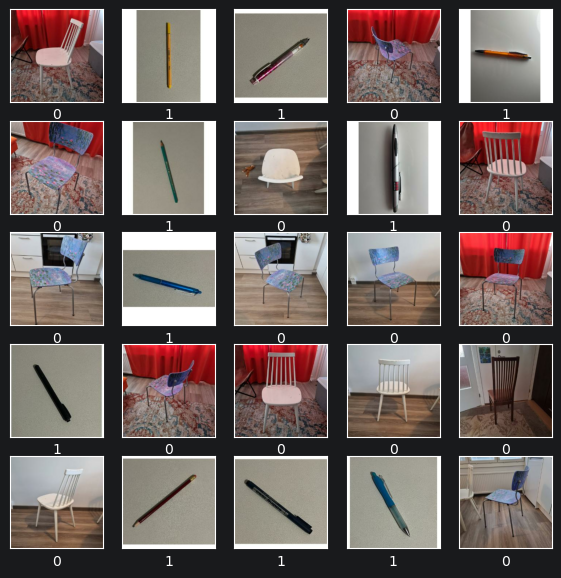

In [38]:
# use plt to visualize some of the images
plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(y_train[i])
plt.show()

# Building and training our own convolutional neural network

Let's build our convolutional neural network from scratch using Keras. We will use data augmentation to help prevent overfitting, and we will also compute class weights to handle any class imbalance in our dataset.

In [39]:

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)


callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]


Class weights: {0: 0.8488372093023255, 1: 1.2166666666666666}


In [40]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']

)

In [42]:
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(x_val, y_val),
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5479 - loss: 0.7042 - val_accuracy: 0.7500 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 664ms/step - accuracy: 0.5205 - loss: 0.6834 - val_accuracy: 0.4375 - val_loss: 0.6866 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.4521 - loss: 0.6701 - val_accuracy: 0.4375 - val_loss: 0.6812 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.5616 - loss: 0.6617 - val_accuracy: 0.5625 - val_loss: 0.6625 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - accuracy: 0.5342 - loss: 0.6485 - val_accuracy: 0.5625 - val_loss: 0.6463 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.5479 - loss: 0.6311 - val_accuracy: 0.7500 - val_loss: 0.6148 - learning_rate: 0.0010
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - accuracy: 0.6986 - loss: 0.6071 - val_accuracy: 1.

In [43]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.1257
Test accuracy: 1.0000


In [44]:
# Generate predictions and confusion matrix
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


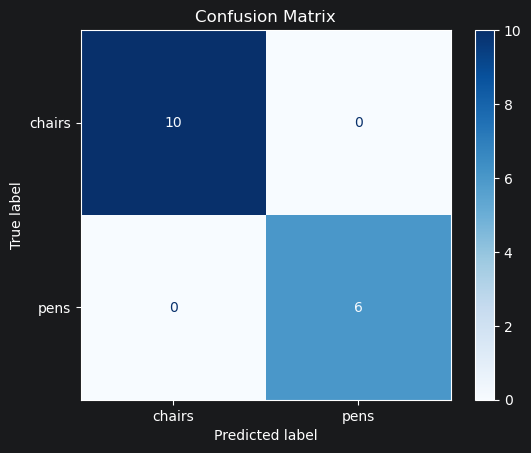

In [45]:
#Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

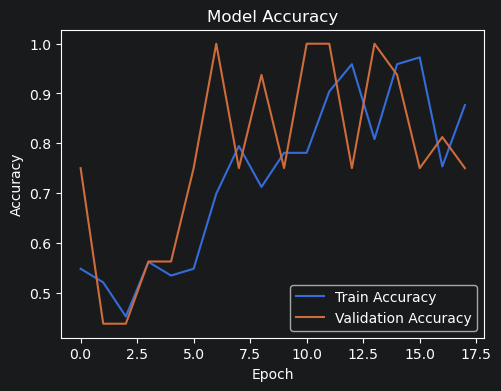

In [46]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()



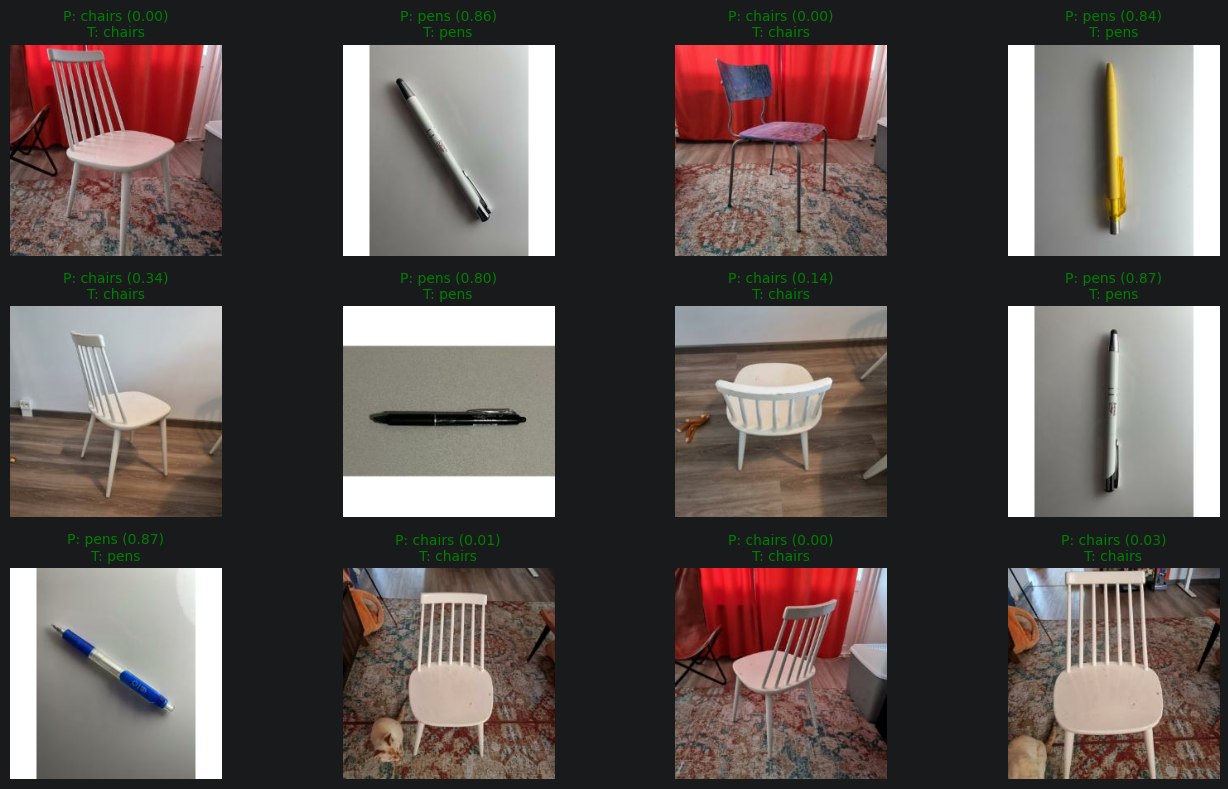

In [47]:
# Plot predictions: predicted vs actual labels for a few test images
num_images = 12
indices = np.random.choice(len(x_test), size=min(num_images, len(x_test)), replace=False)

plt.figure(figsize=(14, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")

    # Force scalar -> Python int for safe list indexing
    true_idx = int(np.asarray(y_test[idx]).squeeze())
    pred_idx = int(np.asarray(y_pred[idx]).squeeze())

    # y_pred_prob[idx] may be shape (1,), so squeeze first
    pred_prob = float(np.asarray(y_pred_prob[idx]).squeeze())

    true_label = dataset.class_names[true_idx]
    pred_label = dataset.class_names[pred_idx]

    color = "green" if true_idx == pred_idx else "red"
    plt.title(f"P: {pred_label} ({pred_prob:.2f})\nT: {true_label}", color=color, fontsize=10)

plt.tight_layout()
plt.show()


